# Lab 8: Heuristic Search Algorithms

## Setup

In [1]:
import matplotlib.colors as mcolors
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import heapq
from collections import deque
import numpy as np

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 7)
plt.rcParams['figure.dpi'] = 100

## Part 1: Building a Weighted Graph with Heuristic Values

### 1.2 Building the Graph

In [2]:
# Build the Ireland map as a weighted graph
ireland = nx.Graph()

# Add edges with distances (km)
ireland.add_edge('Galway', 'Limerick', weight=105)
ireland.add_edge('Galway', 'Belfast', weight=306)
ireland.add_edge('Limerick', 'Cork', weight=90)
ireland.add_edge('Limerick', 'Dublin', weight=196)
ireland.add_edge('Cork', 'Dublin', weight=260)
ireland.add_edge('Cork', 'Waterford', weight=157)
ireland.add_edge('Dublin', 'Waterford', weight=169)
ireland.add_edge('Belfast', 'Dublin', weight=156)

# Heuristic: straight-line distance to Waterford (km)
heuristic = {
    'Galway': 200,
    'Limerick': 170,
    'Belfast': 270,
    'Cork': 120,
    'Dublin': 130,
    'Waterford': 0,
}

# Store heuristic as node attribute
for city, h in heuristic.items():
    ireland.nodes[city]['h'] = h

print('Cities:', list(ireland.nodes()))
print('\nConnections and distances:')
for u, v, data in ireland.edges(data=True):
    print(f"  {u} <-> {v}: {data['weight']} km")

print('\nHeuristic values (crow-flies distance to Waterford):')
for city, h in sorted(heuristic.items(), key=lambda x: x[1]):
    print(f'  {city}: h = {h} km')

Cities: ['Galway', 'Limerick', 'Belfast', 'Cork', 'Dublin', 'Waterford']

Connections and distances:
  Galway <-> Limerick: 105 km
  Galway <-> Belfast: 306 km
  Limerick <-> Cork: 90 km
  Limerick <-> Dublin: 196 km
  Belfast <-> Dublin: 156 km
  Cork <-> Dublin: 260 km
  Cork <-> Waterford: 157 km
  Dublin <-> Waterford: 169 km

Heuristic values (crow-flies distance to Waterford):
  Waterford: h = 0 km
  Cork: h = 120 km
  Dublin: h = 130 km
  Limerick: h = 170 km
  Galway: h = 200 km
  Belfast: h = 270 km


### 1.3 Visualising the Ireland Map

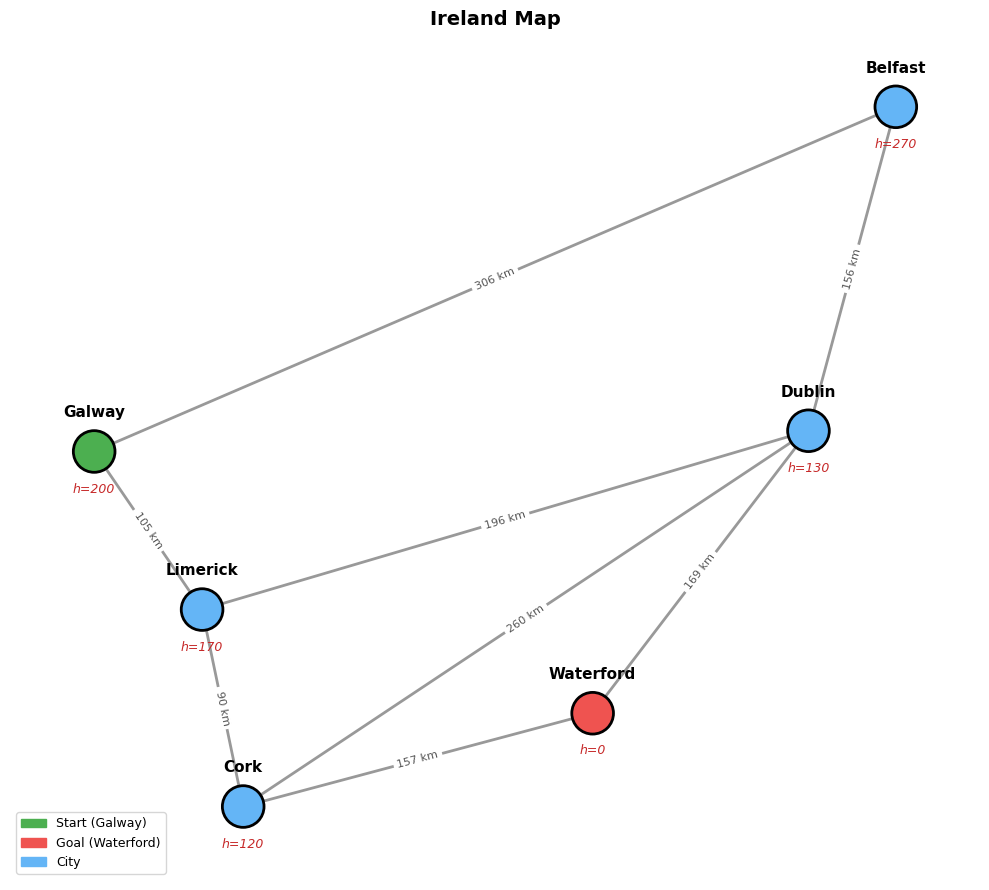

In [3]:
# Geographic-ish positions for Irish cities
ireland_pos = {
    'Galway': (-9.05, 53.27),
    'Limerick': (-8.63, 52.66),
    'Cork': (-8.47, 51.90),
    'Waterford': (-7.11, 52.26),
    'Dublin': (-6.27, 53.35),
    'Belfast': (-5.93, 54.60),
}


def draw_ireland(graph, pos, h, title='Ireland Map', highlight_path=None,
                 highlight_cost=None, extra_nodes=None, extra_h=None):
    """Draw the Ireland map with distances and heuristic values."""
    fig, ax = plt.subplots(figsize=(10, 9))

    all_h = dict(h)
    if extra_h:
        all_h.update(extra_h)

    # Node colours
    node_colors = []
    for n in graph.nodes():
        if n == 'Galway':
            node_colors.append('#4CAF50')
        elif n == 'Waterford':
            node_colors.append('#EF5350')
        else:
            node_colors.append('#64B5F6')

    # Draw edges with distance labels
    nx.draw_networkx_edges(graph, pos, ax=ax, edge_color='#999999', width=2)
    edge_labels = {(u, v): f"{d['weight']} km" for u,
                   v, d in graph.edges(data=True)}
    nx.draw_networkx_edge_labels(
        graph,
        pos,
        edge_labels=edge_labels,
        ax=ax,
        font_size=8,
        font_color='#555555',
    )

    # Highlight path if provided
    if highlight_path:
        path_edges = list(zip(highlight_path[:-1], highlight_path[1:]))
        nx.draw_networkx_edges(
            graph,
            pos,
            edgelist=path_edges,
            edge_color='#E91E63',
            width=2,
            ax=ax,
        )

    # Draw nodes
    nx.draw_networkx_nodes(
        graph,
        pos,
        ax=ax,
        node_color=node_colors,
        node_size=900,
        edgecolors='black',
        linewidths=2,
    )

    # Labels: city name and h(n) value
    for node, (x, y) in pos.items():
        ax.text(x, y + 0.12, node, ha='center',
                va='bottom', fontsize=11, fontweight='bold')
        if node in all_h:
            ax.text(
                x,
                y - 0.12,
                f'h={all_h[node]}',
                ha='center',
                va='top',
                fontsize=9,
                color='#C62828',
                fontstyle='italic',
            )

    # Legend
    legend_items = [
        mpatches.Patch(color='#4CAF50', label='Start (Galway)'),
        mpatches.Patch(color='#EF5350', label='Goal (Waterford)'),
        mpatches.Patch(color='#64B5F6', label='City'),
    ]
    if highlight_path:
        cost_str = f' (cost: {highlight_cost} km)' if highlight_cost else ''
        legend_items.append(
            mpatches.Patch(
                color='#E91E63',
                label=f"Path: {' → '.join(highlight_path)}{cost_str}",
            )
        )
    ax.legend(handles=legend_items, loc='lower left', fontsize=9)

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()


draw_ireland(ireland, ireland_pos, heuristic)

### 1.4 Admissibility and Consistency

In [4]:
# Check admissibility: h(n) <= actual shortest distance to Waterford
print('Admissibility Check')
print('=' * 60)

# Shortest path lengths from Waterford to all reachable cities (Dijkstra)
shortest_to_goal = nx.single_source_dijkstra_path_length(
    ireland,
    'Waterford',
    weight='weight',
)

admissibility_violations = []
for city in sorted(ireland.nodes()):
    actual = shortest_to_goal[city]
    h = heuristic[city]
    admissible = h <= actual
    if not admissible:
        admissibility_violations.append(city)

    line = (
        f"  {city:>10}: h={h:>3}, actual shortest={actual:>3}, "
        f"h <= actual? {admissible} "
        f"{'✓' if admissible else '✗ NOT ADMISSIBLE'}"
    )
    print(line)

# Check consistency: h(n) <= c(n,n') + h(n') for all edges
print('\nConsistency Check (Triangle Inequality)')
print('=' * 60)
all_consistent = True
for u, v, data in ireland.edges(data=True):
    c = data['weight']
    for n, np_ in [(u, v), (v, u)]:
        satisfied = heuristic[n] <= c + heuristic[np_]
        if not satisfied:
            all_consistent = False

        line = (
            f"  h({n})={heuristic[n]} <= c({n},{np_})={c} + "
            f"h({np_})={heuristic[np_]} = {c + heuristic[np_]}? "
            f"{satisfied} {'✓' if satisfied else '✗'}"
        )
        print(line)

if admissibility_violations:
    print(f"\nAdmissibility violations found: {admissibility_violations}")
else:
    print('\nNo admissibility violations found.')

status = (
    'consistent (and therefore admissible)'
    if all_consistent else
    'NOT consistent'
)
print(f'Heuristic is {status}.')

Admissibility Check
     Belfast: h=270, actual shortest=325, h <= actual? True ✓
        Cork: h=120, actual shortest=157, h <= actual? True ✓
      Dublin: h=130, actual shortest=169, h <= actual? True ✓
      Galway: h=200, actual shortest=352, h <= actual? True ✓
    Limerick: h=170, actual shortest=247, h <= actual? True ✓
   Waterford: h=  0, actual shortest=  0, h <= actual? True ✓

Consistency Check (Triangle Inequality)
  h(Galway)=200 <= c(Galway,Limerick)=105 + h(Limerick)=170 = 275? True ✓
  h(Limerick)=170 <= c(Limerick,Galway)=105 + h(Galway)=200 = 305? True ✓
  h(Galway)=200 <= c(Galway,Belfast)=306 + h(Belfast)=270 = 576? True ✓
  h(Belfast)=270 <= c(Belfast,Galway)=306 + h(Galway)=200 = 506? True ✓
  h(Limerick)=170 <= c(Limerick,Cork)=90 + h(Cork)=120 = 210? True ✓
  h(Cork)=120 <= c(Cork,Limerick)=90 + h(Limerick)=170 = 260? True ✓
  h(Limerick)=170 <= c(Limerick,Dublin)=196 + h(Dublin)=130 = 326? True ✓
  h(Dublin)=130 <= c(Dublin,Limerick)=196 + h(Limerick)=170 = 3

## Part 2: Hill Climbing (Steepest Ascent)

### 2.2 Hill Climbing Implementation

In [5]:
def hill_climbing(graph, h, start, goal):
    """
    Steepest-ascent hill climbing.

    At each step, selects the unvisited neighbour with the lowest h(n).
    Makes irrevocable choices — no backtracking.

    Returns:
        path:       List of nodes from start to goal
        total_cost: Total distance travelled
        found:      Whether the goal was reached
        trace:      Step-by-step trace for analysis
    """
    current = start
    path = [start]
    visited = {start}
    total_cost = 0
    trace = []

    while current != goal:
        neighbors = []
        for neighbor in graph.neighbors(current):
            if neighbor not in visited:
                dist = graph[current][neighbor]['weight']
                neighbors.append((h[neighbor], neighbor, dist))

        if not neighbors:
            trace.append({'node': current, 'neighbors': [], 'choice': 'STUCK'})
            return path, total_cost, False, trace

        # Sort by heuristic value (ascending)
        neighbors.sort(key=lambda x: x[0])

        trace.append({
            'node': current,
            'neighbors': [(n, hv, d) for hv, n, d in neighbors],
            'choice': neighbors[0][1],
        })

        # Choose the best (lowest h) neighbour — irrevocable!
        _, best_node, dist = neighbors[0]
        visited.add(best_node)
        path.append(best_node)
        total_cost += dist
        current = best_node

    trace.append({'node': goal, 'neighbors': [], 'choice': 'GOAL'})
    return path, total_cost, True, trace

### 2.3 Hill Climbing on the Base Map

Hill Climbing Trace:
Step            At  Neighbours (name, h, dist)  Choice
---------------------------------------------------------------------------
   1        Galway  Limerick(h=170,d=105), Belfast(h=270,d=306)  Limerick
   2      Limerick  Cork(h=120,d=90), Dublin(h=130,d=196)     Cork
   3          Cork  Waterford(h=0,d=157), Dublin(h=130,d=260)  Waterford
   4     Waterford  -                                         GOAL

Reached goal: True
Path: Galway → Limerick → Cork → Waterford
Total distance: 352 km


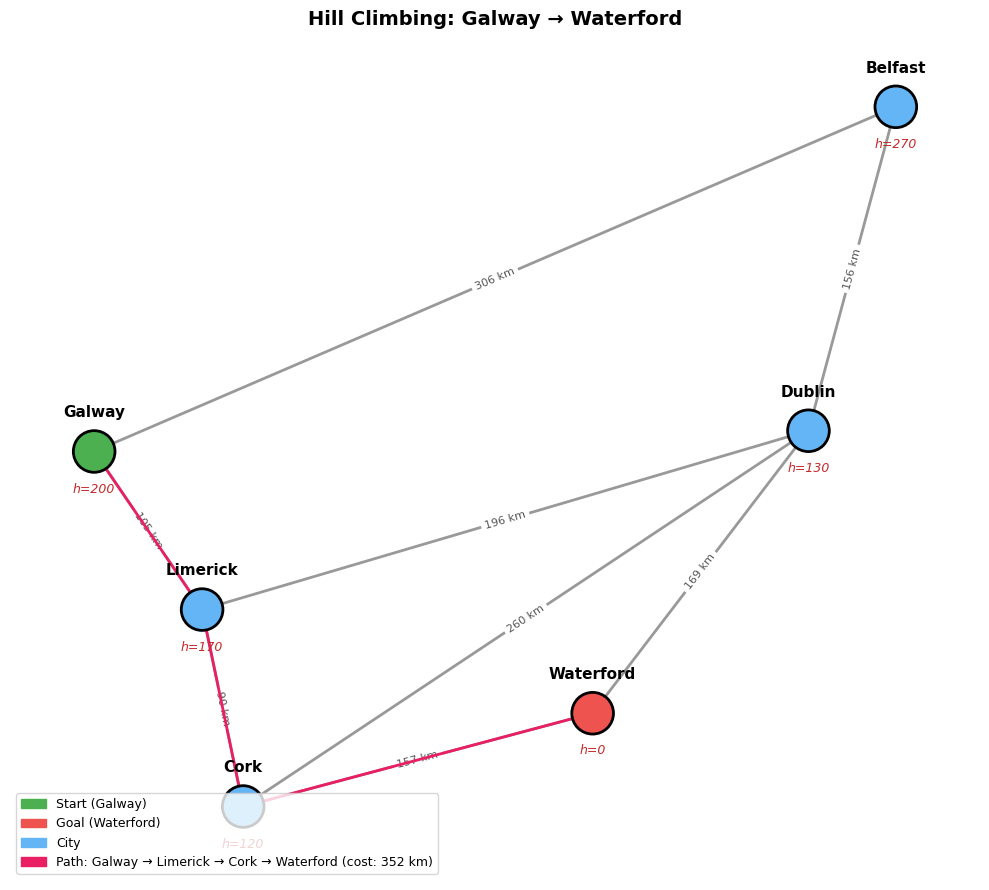

In [6]:
# Run the Hill Climbing search implemented in 2.2
hc_path, hc_cost, hc_ok, hc_trace = hill_climbing(
    ireland, heuristic, 'Galway', 'Waterford')

print('Hill Climbing Trace:')
print(f"{'Step':>4}  {'At':>12}  {'Neighbours (name, h, dist)':}  {'Choice':}")
print('-' * 75)
for i, step in enumerate(hc_trace):
    nbrs = ', '.join(
        f"{n}(h={h},d={d})" for n, h, d in step['neighbors']
    ) if step['neighbors'] else '-'
    print(f"{i + 1:>4}  {step['node']:>12}  {nbrs:<40}  {step['choice']}")

print(f"\nReached goal: {hc_ok}")
print(f"Path: {' → '.join(hc_path)}")
print(f'Total distance: {hc_cost} km')

draw_ireland(
    ireland,
    ireland_pos,
    heuristic,
    title='Hill Climbing: Galway → Waterford',
    highlight_path=hc_path,
    highlight_cost=hc_cost,
)

### 2.4 Foothills: Adding Athlone

Hill Climbing with Athlone (foothill):
Step            At  Neighbours (name, h, dist)  Choice
---------------------------------------------------------------------------
   1        Galway  Athlone(h=90,d=80), Limerick(h=170,d=105), Belfast(h=270,d=306)  Athlone
   2       Athlone  Belfast(h=270,d=300)                      Belfast
   3       Belfast  Dublin(h=130,d=156)                       Dublin
   4        Dublin  Waterford(h=0,d=169), Cork(h=120,d=260), Limerick(h=170,d=196)  Waterford
   5     Waterford  -                                         GOAL

Reached goal: True
Path: Galway → Athlone → Belfast → Dublin → Waterford
Total distance: 705 km
Optimal path was: Galway → Limerick → Cork → Waterford = 352 km
Hill climbing was sidetracked: cost 705 km (353 km extra!)


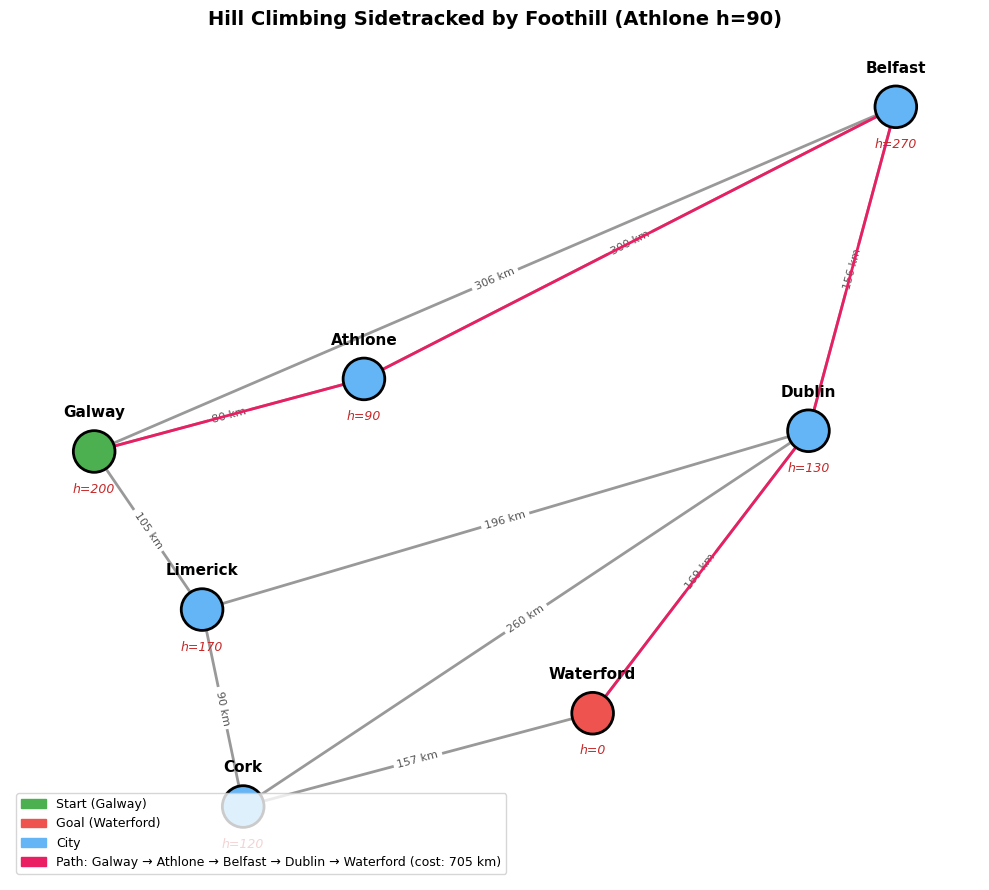

In [7]:
# Add Athlone to create a foothill
ireland_fh = ireland.copy()
ireland_fh.add_edge('Galway', 'Athlone', weight=80)
ireland_fh.add_edge('Athlone', 'Belfast', weight=300)

h_fh = dict(heuristic)
h_fh['Athlone'] = 90  # Deceptively low heuristic

# Update positions
pos_fh = dict(ireland_pos)
pos_fh['Athlone'] = (-8.0, 53.55)

# Run Hill Climbing on the map with a foothill
hc_fh_path, hc_fh_cost, hc_fh_ok, hc_fh_trace = hill_climbing(
    ireland_fh,
    h_fh,
    'Galway',
    'Waterford',
)

print('Hill Climbing with Athlone (foothill):')
print(f"{'Step':>4}  {'At':>12}  {'Neighbours (name, h, dist)':}  {'Choice':}")
print('-' * 75)
for i, step in enumerate(hc_fh_trace):
    nbrs = ', '.join(
        f"{n}(h={h},d={d})" for n, h, d in step['neighbors']
    ) if step['neighbors'] else '-'
    print(f"{i + 1:>4}  {step['node']:>12}  {nbrs:<40}  {step['choice']}")

print(f"\nReached goal: {hc_fh_ok}")
print(f"Path: {' → '.join(hc_fh_path)}")
print(f'Total distance: {hc_fh_cost} km')
print('Optimal path was: Galway → Limerick → Cork → Waterford = 352 km')
print(
    f'Hill climbing was sidetracked: cost {hc_fh_cost} km ({
        hc_fh_cost -
        352} km extra!)')

draw_ireland(
    ireland_fh,
    pos_fh,
    heuristic,
    extra_h={'Athlone': 90},
    title='Hill Climbing Sidetracked by Foothill (Athlone h=90)',
    highlight_path=hc_fh_path,
    highlight_cost=hc_fh_cost,
)

### 2.5 Plateaux: Adding Nenagh and Adjusting Athlone

Hill Climbing with Plateaux:
Step            At  Neighbours (name, h, dist)  Choice
--------------------------------------------------------------------------------
   1        Galway  Limerick(h=170,d=105), Athlone(h=170,d=80), Belfast(h=270,d=306)  ** TIE **  Limerick
   2      Limerick  Cork(h=120,d=90), Nenagh(h=120,d=40), Dublin(h=130,d=196)  ** TIE **  Cork
   3          Cork  Waterford(h=0,d=157), Dublin(h=130,d=260)                Waterford
   4     Waterford  -                                                        GOAL

Reached goal: True
Path: Galway → Limerick → Cork → Waterford
Total distance: 352 km
Optimal path: Galway → Limerick → Cork → Waterford = 352 km
Penalty: 0 km extra


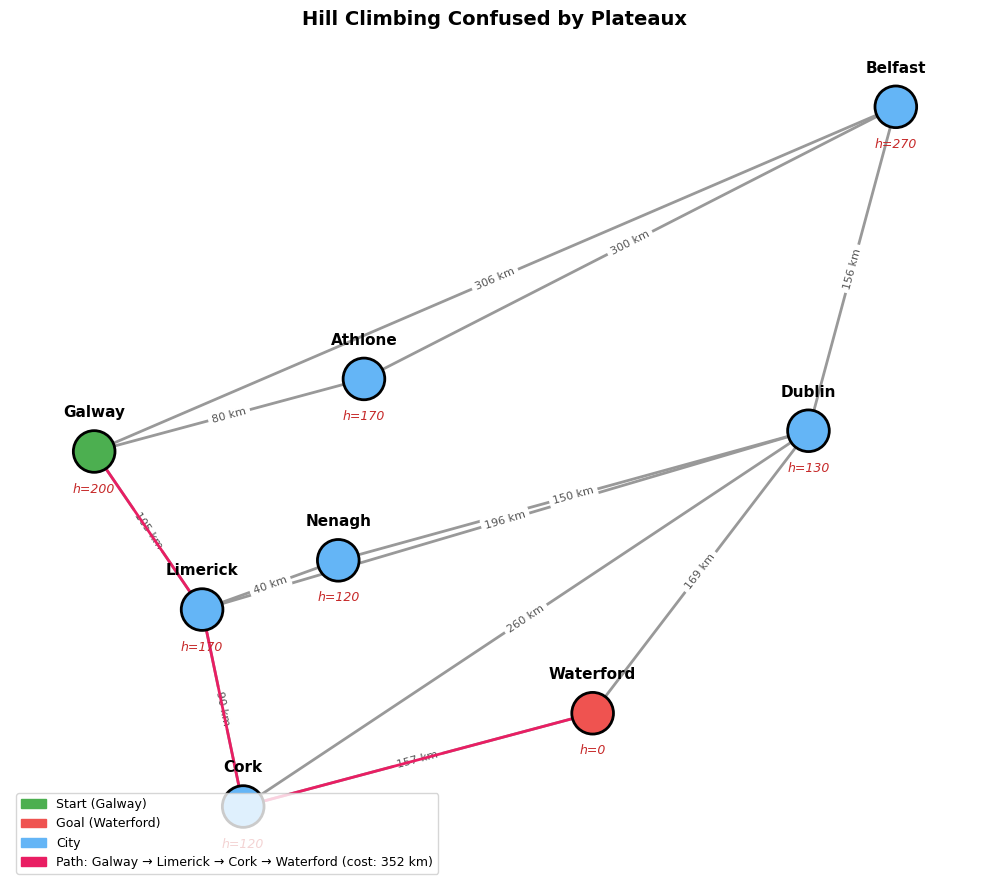

In [8]:
# Build the plateau map
ireland_pl = ireland_fh.copy()

# Adjust Athlone heuristic to match Limerick (plateau)
h_pl = dict(heuristic)
h_pl['Athlone'] = 170  # same as Limerick!

# Add Nenagh connected to Limerick and Dublin
# Weights: Limerick-Nenagh = 40, Nenagh-Dublin = 150
ireland_pl.add_edge('Limerick', 'Nenagh', weight=40)
ireland_pl.add_edge('Nenagh', 'Dublin', weight=150)

# Add Nenagh with h=120 (same as Cork)
h_pl['Nenagh'] = 120

pos_pl = dict(ireland_pos)
pos_pl['Athlone'] = (-8.0, 53.55)
pos_pl['Nenagh'] = (-8.1, 52.85)

# Run Hill Climbing on the map with plateaux
hc_pl_path, hc_pl_cost, hc_pl_ok, hc_pl_trace = hill_climbing(
    ireland_pl,
    h_pl,
    'Galway',
    'Waterford',
)

print('Hill Climbing with Plateaux:')
print(f"{'Step':>4}  {'At':>12}  {'Neighbours (name, h, dist)':}  {'Choice':}")
print('-' * 80)
for i, step in enumerate(hc_pl_trace):
    nbrs = ', '.join(
        f"{n}(h={h},d={d})" for n, h, d in step['neighbors']
    ) if step['neighbors'] else '-'

    # Highlight ties
    if step['neighbors'] and len(step['neighbors']) > 1:
        h_values = [h for n, h, d in step['neighbors']]
        if h_values[0] == h_values[1]:
            nbrs += '  ** TIE **'

    print(f"{i + 1:>4}  {step['node']:>12}  {nbrs:<55}  {step['choice']}")

print(f"\nReached goal: {hc_pl_ok}")
print(f"Path: {' → '.join(hc_pl_path)}")
print(f'Total distance: {hc_pl_cost} km')
print('Optimal path: Galway → Limerick → Cork → Waterford = 352 km')
print(f'Penalty: {hc_pl_cost - 352} km extra')

draw_ireland(
    ireland_pl,
    pos_pl,
    heuristic,
    extra_h={'Athlone': 170, 'Nenagh': 120},
    title='Hill Climbing Confused by Plateaux',
    highlight_path=hc_pl_path,
    highlight_cost=hc_pl_cost,
)

## Part 3: Greedy Best-First Search

### 3.2 Greedy Best-First Implementation

In [9]:
def greedy_best_first(graph, h, start, goal):
    """
    Greedy Best-First Search using a priority queue sorted by h(n).

    Returns:
        path:       Path from start to goal
        total_cost: Actual distance of the path
        expanded:   Number of nodes expanded
        trace:      Step-by-step trace
    """
    visited = set()
    # Priority queue: (h(n), node, path, cost)
    pq = [(h[start], start, [start], 0)]
    expanded = 0
    trace = []

    while pq:
        h_val, node, path, cost = heapq.heappop(pq)

        if node in visited:
            continue
        visited.add(node)
        expanded += 1

        # Record trace
        open_nodes = [(hv, n) for hv, n, _, _ in pq if n not in visited]
        trace.append({
            'visiting': node, 'h': h_val, 'cost_so_far': cost,
            'open': sorted(set(open_nodes)),
            'closed': sorted(visited)
        })

        if node == goal:
            return path, cost, expanded, trace

        for neighbor in graph.neighbors(node):
            if neighbor not in visited:
                dist = graph[node][neighbor]['weight']
                heapq.heappush(pq, (h[neighbor], neighbor,
                               path + [neighbor], cost + dist))

    return None, 0, expanded, trace

In [10]:
# Run the implemented Greedy Best First search (3.2) on the original map (1.2)
gbf_path, gbf_cost, gbf_exp, gbf_trace = greedy_best_first(
    ireland,
    heuristic,
    'Galway',
    'Waterford',
)

print('Greedy Best-First Search Trace:')
header = (
    f"{'Step':>4}  {'Visiting':>12}  "
    f"{'h(n)':>5}  {'Cost':>6}  {'Open Queue':}"
)
print(header)
print('-' * 70)
for i, step in enumerate(gbf_trace):
    open_str = ', '.join(
        f"{n}(h={h})" for h, n in step['open']
    ) if step['open'] else 'empty'

    line = (
        f"{i + 1:>4}  {step['visiting']:>12}  {step['h']:>5}  "
        f"{step['cost_so_far']:>6}  {open_str}"
    )
    print(line)

path_text = ' → '.join(gbf_path)
print(f"\nPath: {path_text}, cost = {gbf_cost} km, nodes expanded = {gbf_exp}")

Greedy Best-First Search Trace:
Step      Visiting   h(n)    Cost  Open Queue
----------------------------------------------------------------------
   1        Galway    200       0  empty
   2      Limerick    170     105  Belfast(h=270)
   3          Cork    120     195  Dublin(h=130), Belfast(h=270)
   4     Waterford      0     352  Dublin(h=130), Belfast(h=270)

Path: Galway → Limerick → Cork → Waterford, cost = 352 km, nodes expanded = 4


## Part 4: Beam Search

### 4.2 Beam Search Implementation

In [11]:
def beam_search(graph, h, start, goal, beam_width=2):
    """
    Beam Search: BFS-style level expansion with a beam width limit.
    At each level, keeps only the beam_width best nodes (lowest h).

    Returns:
        path:      Path from start to goal
        cost:      Total path cost
        expanded:  Number of nodes expanded
        trace:     Level-by-level trace
    """
    # Each entry: (h, node, path, cost)
    current_level = [(h[start], start, [start], 0)]
    visited = {start}
    expanded = 0
    trace = []

    while current_level:
        trace.append({
            'level_nodes': [(n, hv) for hv, n, _, _ in current_level],
        })

        next_level = []
        for h_val, node, path, cost in current_level:
            expanded += 1

            if node == goal:
                return path, cost, expanded, trace

            for neighbor in graph.neighbors(node):
                if neighbor not in visited:
                    dist = graph[node][neighbor]['weight']
                    next_level.append(
                        (
                            h[neighbor],
                            neighbor,
                            path + [neighbor],
                            cost + dist,
                        )
                    )

        # Sort next_level by h(n)
        next_level.sort(key=lambda x: x[0])

        # Keep only beam_width best candidates
        current_level = []
        for item in next_level[:beam_width]:
            _, node, _, _ = item
            if node not in visited:
                visited.add(node)
                current_level.append(item)

    return None, 0, expanded, trace


# Run the implemented Beam Search on the original map (1.2)
beam_path, beam_cost, beam_exp, beam_trace = beam_search(
    ireland,
    heuristic,
    'Galway',
    'Waterford',
    beam_width=2,
)

# Beam search with width 2
beam_line = (
    f"Beam Search (w=2): {' → '.join(beam_path)}, "
    f"cost = {beam_cost} km, expanded = {beam_exp}"
)
print(beam_line)
print('\nLevel-by-level:')
for i, level in enumerate(beam_trace):
    nodes_str = ', '.join(f"{n}(h={h})" for n, h in level['level_nodes'])
    print(f'  Level {i}: {nodes_str}')

# Compare with width 1 and width 3
for w in [1, 3]:
    bp, bc, be, _ = beam_search(
        ireland,
        heuristic,
        'Galway',
        'Waterford',
        beam_width=w,
    )

    if bp:
        print(
            f"\nBeam Search (w={w}): {' → '.join(bp)}, "
            f"cost = {bc} km, expanded = {be}"
        )
    else:
        print(f"\nBeam Search (w={w}): FAILED to find a path")

Beam Search (w=2): Galway → Limerick → Cork → Waterford, cost = 352 km, expanded = 6

Level-by-level:
  Level 0: Galway(h=200)
  Level 1: Limerick(h=170), Belfast(h=270)
  Level 2: Cork(h=120), Dublin(h=130)
  Level 3: Waterford(h=0)

Beam Search (w=1): Galway → Limerick → Cork → Waterford, cost = 352 km, expanded = 4

Beam Search (w=3): Galway → Limerick → Cork → Waterford, cost = 352 km, expanded = 6


## Part 5: A* Search

### 5.2 A* Implementation

In [12]:
def a_star(graph, h, start, goal):
    """
    A* Search with OPEN/CLOSED list tracing.

    Uses f(n) = g(n) + h(n) to select the most promising node.

    Returns:
        path:      Optimal path from start to goal
        cost:      Optimal path cost
        expanded:  Number of nodes expanded
        trace:     Step-by-step trace showing OPEN and CLOSED lists
    """
    visited = set()  # CLOSED list
    g_costs = {start: 0}  # Best known g(n) for each node

    # OPEN list: priority queue of (f(n), g(n), node, path)
    pq = [(h[start], 0, start, [start])]
    expanded = 0
    trace = []

    while pq:
        f_val, g_val, node, path = heapq.heappop(pq)

        if node in visited:
            continue

        visited.add(node)
        expanded += 1

        # Build trace entry
        open_list = []
        for f_, g_, n_, _ in pq:
            if n_ not in visited:
                open_list.append((n_, f_, g_, h[n_]))

        # Deduplicate (keep best f for each node)
        open_dict = {}
        for n_, f_, g_, h_ in open_list:
            if n_ not in open_dict or f_ < open_dict[n_][0]:
                open_dict[n_] = (f_, g_, h_)

        trace.append({
            'visiting': node,
            'f': f_val,
            'g': g_val,
            'h': h[node],
            'open': {n: vals for n, vals in sorted(open_dict.items())},
            'closed': sorted(visited),
        })

        if node == goal:
            return path, g_val, expanded, trace

        # Expand neighbours
        for neighbor in graph.neighbors(node):
            if neighbor not in visited:
                dist = graph[node][neighbor]['weight']
                new_g = g_val + dist

                if neighbor not in g_costs or new_g < g_costs[neighbor]:
                    g_costs[neighbor] = new_g
                    new_f = new_g + h[neighbor]
                    heapq.heappush(
                        pq, (new_f, new_g, neighbor, path + [neighbor]))

    return None, 0, expanded, trace

### 5.3 A* on the Ireland Map

A* Search Trace (OPEN and CLOSED lists)

Step 1: Visit Galway [f=200, g=0, h=200]
  OPEN:   empty
  CLOSED: ['Galway']

Step 2: Visit Limerick [f=275, g=105, h=170]
  OPEN:   Belfast(f=576, g=306, h=270)
  CLOSED: ['Galway', 'Limerick']

Step 3: Visit Cork [f=315, g=195, h=120]
  OPEN:   Belfast(f=576, g=306, h=270), Dublin(f=431, g=301, h=130)
  CLOSED: ['Cork', 'Galway', 'Limerick']

Step 4: Visit Waterford [f=352, g=352, h=0]
  OPEN:   Belfast(f=576, g=306, h=270), Dublin(f=431, g=301, h=130)
  CLOSED: ['Cork', 'Galway', 'Limerick', 'Waterford']

Optimal path: Galway → Limerick → Cork → Waterford
Optimal cost: 352 km
Nodes expanded: 4


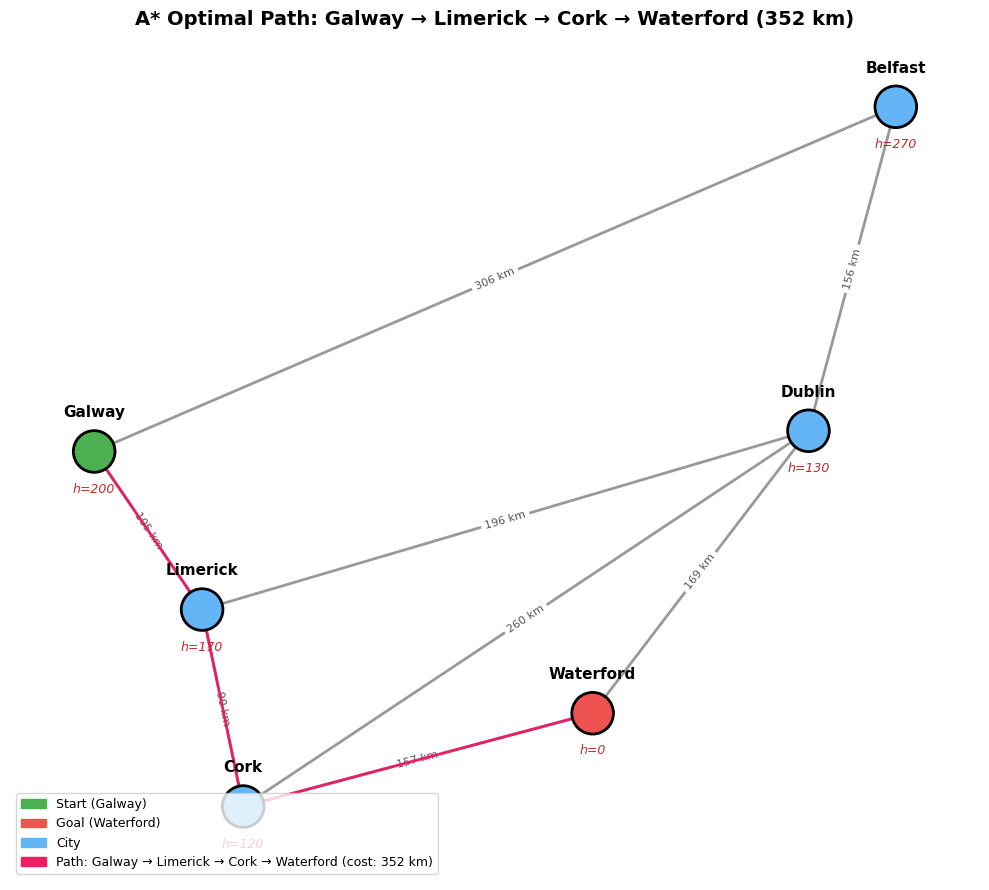

In [13]:
# Run A* implemented in 5.2 on the original map (1.2)
astar_path, astar_cost, astar_exp, astar_trace = a_star(
    ireland,
    heuristic,
    'Galway',
    'Waterford',
)

print('A* Search Trace (OPEN and CLOSED lists)')
print('=' * 85)
for i, step in enumerate(astar_trace):
    print(
        f"\nStep {i + 1}: Visit {step['visiting']} "
        f"[f={step['f']}, g={step['g']}, h={step['h']}]"
    )

    if step['open']:
        print('  OPEN:   ', end='')
        parts = []
        for n, (f, g, h_) in step['open'].items():
            parts.append(f'{n}(f={f}, g={g}, h={h_})')
        print(', '.join(parts))
    else:
        print('  OPEN:   empty')

    print(f"  CLOSED: {step['closed']}")

print(f"\nOptimal path: {' → '.join(astar_path)}")
print(f'Optimal cost: {astar_cost} km')
print(f'Nodes expanded: {astar_exp}')

draw_ireland(
    ireland,
    ireland_pos,
    heuristic,
    title=f"A* Optimal Path: {' → '.join(astar_path)} ({astar_cost} km)",
    highlight_path=astar_path,
    highlight_cost=astar_cost,
)

### 5.4 A* with the Athlone Foothill

In [14]:
h_fh_full = dict(heuristic)
h_fh_full['Athlone'] = 90

# Run A* implemented in 5.2 on the map with a foothill (2.4)
astar_fh_path, astar_fh_cost, astar_fh_exp, astar_fh_trace = a_star(
    ireland_fh,
    h_fh_full,
    'Galway',
    'Waterford',
)

print('A* with Athlone foothill:')
print('=' * 85)
for i, step in enumerate(astar_fh_trace):
    print(
        f"\nStep {i + 1}: Visit {step['visiting']} "
        f"[f={step['f']}, g={step['g']}, h={step['h']}]"
    )

    if step['open']:
        print('  OPEN:   ', end='')
        parts = []
        for n, (f, g, h_) in step['open'].items():
            parts.append(f'{n}(f={f}, g={g}, h={h_})')
        print(', '.join(parts))
    else:
        print('  OPEN:   empty')

    print(f"  CLOSED: {step['closed']}")

print(f"\nA* path: {' → '.join(astar_fh_path)}, cost = {astar_fh_cost} km")
print(
    'Hill climbing path was: '
    'Galway → Athlone → Belfast → Dublin → Waterford, cost = 705 km'
)
print(
    '\nA* is not sidetracked because it evaluates '
    'f(n) = g(n) + h(n), not only h(n).'
)
print(
    'Athlone starts with f(Athlone) = 80 + 90 = 170, '
    'but the continuation through Athlone grows expensive.'
)
print(
    'The Limerick/Cork route remains globally better '
    'and A* recovers the cheaper solution.'
)

A* with Athlone foothill:

Step 1: Visit Galway [f=200, g=0, h=200]
  OPEN:   empty
  CLOSED: ['Galway']

Step 2: Visit Athlone [f=170, g=80, h=90]
  OPEN:   Belfast(f=576, g=306, h=270), Limerick(f=275, g=105, h=170)
  CLOSED: ['Athlone', 'Galway']

Step 3: Visit Limerick [f=275, g=105, h=170]
  OPEN:   Belfast(f=576, g=306, h=270)
  CLOSED: ['Athlone', 'Galway', 'Limerick']

Step 4: Visit Cork [f=315, g=195, h=120]
  OPEN:   Belfast(f=576, g=306, h=270), Dublin(f=431, g=301, h=130)
  CLOSED: ['Athlone', 'Cork', 'Galway', 'Limerick']

Step 5: Visit Waterford [f=352, g=352, h=0]
  OPEN:   Belfast(f=576, g=306, h=270), Dublin(f=431, g=301, h=130)
  CLOSED: ['Athlone', 'Cork', 'Galway', 'Limerick', 'Waterford']

A* path: Galway → Limerick → Cork → Waterford, cost = 352 km
Hill climbing path was: Galway → Athlone → Belfast → Dublin → Waterford, cost = 705 km

A* is not sidetracked because it evaluates f(n) = g(n) + h(n), not only h(n).
Athlone starts with f(Athlone) = 80 + 90 = 170, but t

### 5.5 Verifying with NetworkX

In [15]:
# NetworkX A* — pass our heuristic function
def nx_heuristic(n, goal):
    return heuristic[n]


nx_path = nx.astar_path(
    ireland,
    'Galway',
    'Waterford',
    heuristic=nx_heuristic,
    weight='weight',
)
nx_cost = nx.astar_path_length(
    ireland,
    'Galway',
    'Waterford',
    heuristic=nx_heuristic,
    weight='weight',
)

print(f'Our A* path:     {astar_path}, cost = {astar_cost} km')
print(f'NetworkX A* path: {list(nx_path)}, cost = {nx_cost} km')
print(f"Match: {astar_path == list(nx_path) and astar_cost == nx_cost}")

Our A* path:     ['Galway', 'Limerick', 'Cork', 'Waterford'], cost = 352 km
NetworkX A* path: ['Galway', 'Limerick', 'Cork', 'Waterford'], cost = 352 km
Match: True


## Part 6: Algorithm Comparison

In [16]:
# Run BFS (uninformed search) for comparison (finds fewest-edge path)
# We compute its actual cost only for comparison with the other algorithms.
def bfs(graph, start, goal):
    visited = set()
    queue = deque([(start, [start], 0)])
    expanded = 0

    while queue:
        node, path, cost = queue.popleft()
        if node in visited:
            continue

        visited.add(node)
        expanded += 1

        if node == goal:
            return path, cost, expanded

        for neighbor in graph.neighbors(node):
            if neighbor not in visited:
                dist = graph[node][neighbor]['weight']
                queue.append((neighbor, path + [neighbor], cost + dist))

    return None, 0, expanded


bfs_path, bfs_cost, bfs_exp = bfs(ireland, 'Galway', 'Waterford')

print('Algorithm Comparison: Galway → Waterford')
print('=' * 75)
print(f"{'Algorithm':<25} {'Path':>35} {'Cost (km)':>10} {'Expanded':>9}")
print('-' * 75)

results = [
    ('BFS', bfs_path, bfs_cost, bfs_exp),
    ('Hill Climbing', hc_path, hc_cost, len(hc_trace)),
    ('Greedy Best-First', gbf_path, gbf_cost, gbf_exp),
    ('Beam Search (w=2)', beam_path, beam_cost, beam_exp),
    ('A*', astar_path, astar_cost, astar_exp),
]

for name, path, cost, exp in results:
    path_str = ' → '.join(path) if path else 'NOT FOUND'
    print(f'{name:<25} {path_str:>35} {cost:>10} {exp:>9}')

Algorithm Comparison: Galway → Waterford
Algorithm                                                Path  Cost (km)  Expanded
---------------------------------------------------------------------------
BFS                       Galway → Limerick → Cork → Waterford        352         6
Hill Climbing             Galway → Limerick → Cork → Waterford        352         4
Greedy Best-First         Galway → Limerick → Cork → Waterford        352         4
Beam Search (w=2)         Galway → Limerick → Cork → Waterford        352         6
A*                        Galway → Limerick → Cork → Waterford        352         4


## Part 7: A* with Different Evaluation Functions

### 7.2 Building the Grid World

In [17]:
# Grid world: 7 rows x 10 columns
# 1 = flat, 3 = hills, 5 = swamp, 0 = wall
terrain = np.ones((7, 10), dtype=int)

# Wall across the middle (column 5), rows 1-5
for r in range(1, 6):
    terrain[r, 5] = 0

# Top gap: passable but EXPENSIVE (swamp)
terrain[0, 4] = 5
terrain[0, 5] = 5
terrain[0, 6] = 5
terrain[1, 4] = 3  # hills near the gap
terrain[1, 6] = 3

# Bottom gap: open and flat (but longer route)
terrain[6, 5] = 1

# Some hills on the left side
terrain[3, 3] = 3
terrain[3, 4] = 3
terrain[4, 4] = 3

start = (3, 0)  # middle-left
goal = (3, 9)   # middle-right

# Display the grid
terrain_names = {0: 'Wall', 1: 'Flat', 3: 'Hills', 5: 'Swamp'}
print('Terrain Grid (S = start, G = goal):')
for r in range(7):
    row_str = ''
    for c in range(10):
        if (r, c) == start:
            row_str += ' S '
        elif (r, c) == goal:
            row_str += ' G '
        elif terrain[r, c] == 0:
            row_str += ' ■ '
        else:
            row_str += f' {terrain[r, c]} '
    print(row_str)

print('\nLegend: 1=Flat, 3=Hills, 5=Swamp, ■=Wall')

Terrain Grid (S = start, G = goal):
 1  1  1  1  5  5  5  1  1  1 
 1  1  1  1  3  ■  3  1  1  1 
 1  1  1  1  1  ■  1  1  1  1 
 S  1  1  3  3  ■  1  1  1  G 
 1  1  1  1  3  ■  1  1  1  1 
 1  1  1  1  1  ■  1  1  1  1 
 1  1  1  1  1  1  1  1  1  1 

Legend: 1=Flat, 3=Hills, 5=Swamp, ■=Wall


### 7.3 A* with Different Cost Functions

In [18]:
def manhattan_distance(a, b):
    """Manhattan distance heuristic."""
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


def a_star_grid(grid, start, goal, use_terrain_cost=True):
    """
    A* on a grid world.

    Parameters:
        grid:              2D numpy array of terrain costs (0 = wall)
        start, goal:       (row, col) tuples
        use_terrain_cost:  If True, step cost = terrain value.
                           If False, step cost = 1 (uniform).

    Returns:
        path, cost, expanded, visited
    """
    rows, cols = grid.shape
    visited = set()
    g_costs = {start: 0}

    # Priority queue: (f, g, node, path)
    h_start = manhattan_distance(start, goal)
    pq = [(h_start, 0, start, [start])]
    expanded = 0

    while pq:
        f, g, node, path = heapq.heappop(pq)
        if node in visited:
            continue

        visited.add(node)
        expanded += 1

        if node == goal:
            return path, g, expanded, visited

        r, c = node
        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nr, nc = r + dr, c + dc
            if 0 <= nr < rows and 0 <= nc < cols and grid[nr, nc] != 0:
                neighbor = (nr, nc)
                step_cost = grid[nr, nc] if use_terrain_cost else 1
                new_g = g + step_cost

                if neighbor not in visited and (
                    neighbor not in g_costs or new_g < g_costs[neighbor]
                ):
                    g_costs[neighbor] = new_g
                    h = manhattan_distance(neighbor, goal)
                    new_f = new_g + h
                    heapq.heappush(
                        pq,
                        (new_f, new_g, neighbor, path + [neighbor]),
                    )

    return None, 0, expanded, visited


# A* with uniform cost (shortest distance)
path_dist, cost_dist, exp_dist, visited_dist = a_star_grid(
    terrain,
    start,
    goal,
    use_terrain_cost=False,
)

# A* with terrain cost (cheapest path)
path_cheap, cost_cheap, exp_cheap, visited_cheap = a_star_grid(
    terrain,
    start,
    goal,
    use_terrain_cost=True,
)

# Compute cross-metrics
dist_terrain_cost = sum(terrain[r, c] for r, c in path_dist[1:])
cheap_steps = len(path_cheap) - 1

print('Shortest-distance path (uniform cost):')
print(
    f'  Steps: {len(path_dist) - 1}, '
    f'Terrain cost: {dist_terrain_cost}, Expanded: {exp_dist}'
)

print('\nCheapest-terrain path:')
print(
    f'  Steps: {cheap_steps}, '
    f'Terrain cost: {cost_cheap}, Expanded: {exp_cheap}'
)

if dist_terrain_cost != cost_cheap:
    print(
        f'\nThe shortest path costs {dist_terrain_cost} in terrain - '
        f'{dist_terrain_cost - cost_cheap} more than the cheapest path!'
    )
    print(
        f'The cheapest path takes {cheap_steps - (len(path_dist) - 1)} '
        f'extra steps but saves {dist_terrain_cost - cost_cheap} '
        'in terrain cost.'
    )

Shortest-distance path (uniform cost):
  Steps: 15, Terrain cost: 33, Expanded: 65

Cheapest-terrain path:
  Steps: 15, Terrain cost: 15, Expanded: 51

The shortest path costs 33 in terrain - 18 more than the cheapest path!
The cheapest path takes 0 extra steps but saves 18 in terrain cost.


### 7.4 Visualising Both Paths

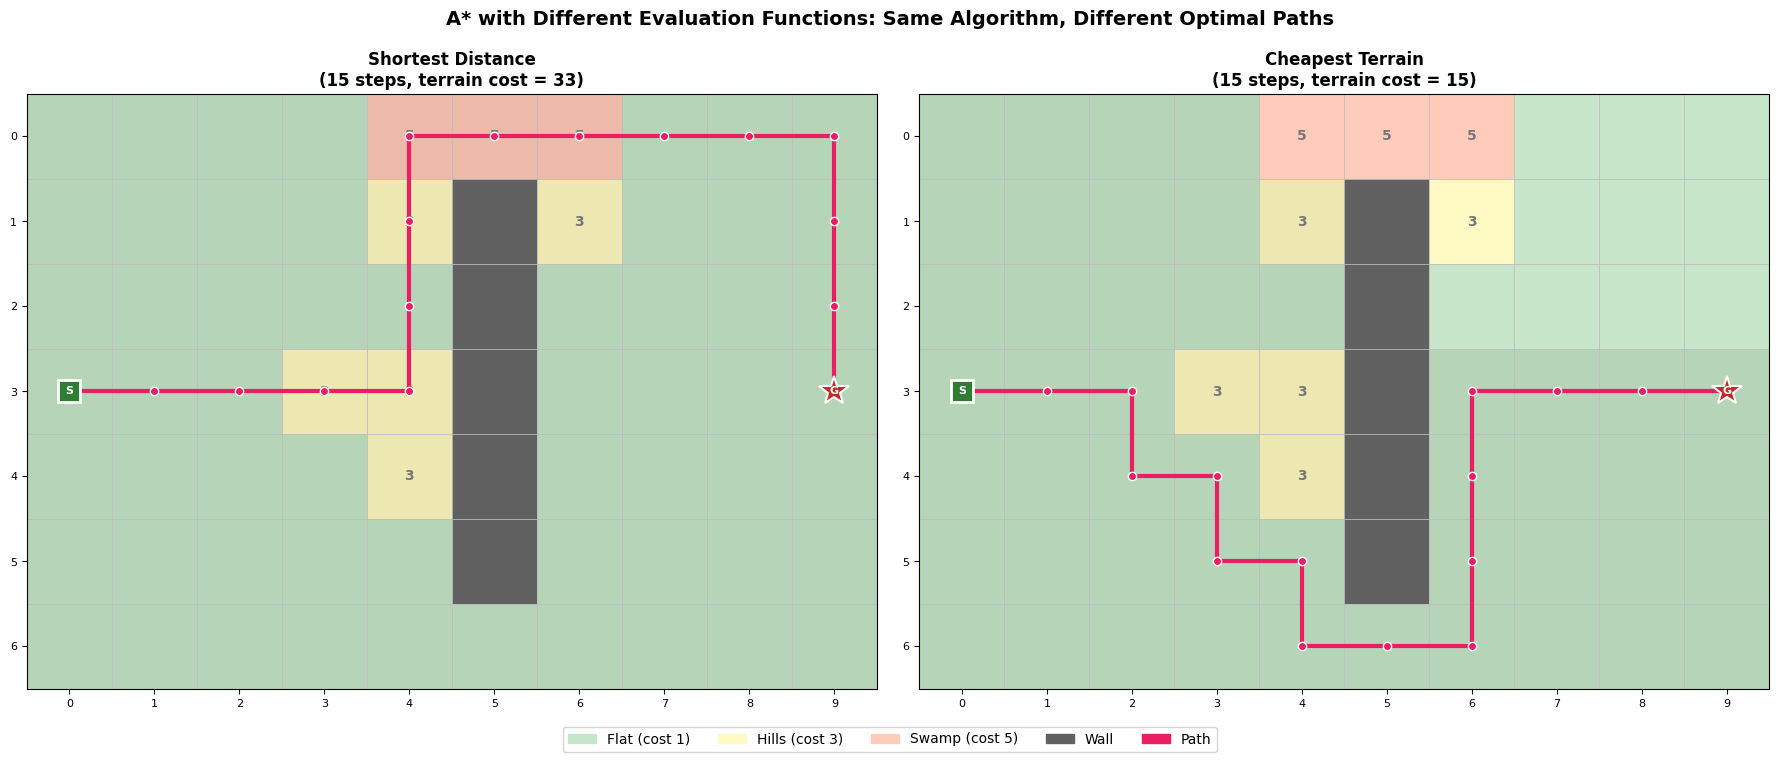

In [19]:
terrain_cmap = {0: '#616161', 1: '#C8E6C9', 3: '#FFF9C4', 5: '#FFCCBC'}
terrain_labels = {0: 'Wall', 1: 'Flat (1)', 3: 'Hills (3)', 5: 'Swamp (5)'}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
title_dist = (
    f'Shortest Distance\n('
    f'{len(path_dist) - 1} steps, terrain cost = {dist_terrain_cost})'
)
title_cheap = (
    f'Cheapest Terrain\n('
    f'{cheap_steps} steps, terrain cost = {cost_cheap})'
)

paths_info = [
    (axes[0], path_dist, title_dist, visited_dist),
    (axes[1], path_cheap, title_cheap, visited_cheap),
]

for ax, path, title, visited_set in paths_info:
    rows, cols = terrain.shape

    # Draw terrain
    for r in range(rows):
        for c in range(cols):
            color = terrain_cmap[terrain[r, c]]

            # Slightly highlight visited cells
            if (r, c) in visited_set and terrain[r, c] != 0:
                rgb = mcolors.to_rgb(color)
                color = tuple(max(0, v - 0.07) for v in rgb)

            rect = plt.Rectangle(
                (c - 0.5, r - 0.5),
                1,
                1,
                facecolor=color,
                edgecolor='#BBBBBB',
                linewidth=0.5,
            )
            ax.add_patch(rect)

            # Show terrain cost in cell
            if terrain[r, c] > 1:
                ax.text(
                    c,
                    r,
                    str(terrain[r, c]),
                    ha='center',
                    va='center',
                    fontsize=10,
                    color='#777777',
                    fontweight='bold',
                )

    # Draw path
    if path:
        path_r = [p[0] for p in path]
        path_c = [p[1] for p in path]
        ax.plot(
            path_c,
            path_r,
            'o-',
            color='#E91E63',
            linewidth=3,
            markersize=6,
            markeredgecolor='white',
            markeredgewidth=1,
            zorder=5,
        )

    # Start and goal markers
    ax.plot(
        start[1],
        start[0],
        's',
        color='#2E7D32',
        markersize=16,
        zorder=6,
        markeredgecolor='white',
        markeredgewidth=2,
    )
    ax.plot(
        goal[1],
        goal[0],
        '*',
        color='#C62828',
        markersize=22,
        zorder=6,
        markeredgecolor='white',
        markeredgewidth=1.5,
    )
    ax.text(
        start[1],
        start[0],
        'S',
        ha='center',
        va='center',
        fontsize=8,
        color='white',
        fontweight='bold',
        zorder=7,
    )
    ax.text(
        goal[1],
        goal[0],
        'G',
        ha='center',
        va='center',
        fontsize=8,
        color='white',
        fontweight='bold',
        zorder=7,
    )

    ax.set_xlim(-0.5, cols - 0.5)
    ax.set_ylim(rows - 0.5, -0.5)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks(range(cols))
    ax.set_yticks(range(rows))
    ax.tick_params(labelsize=8)

# Shared legend
legend_elements = [
    mpatches.Patch(color='#C8E6C9', label='Flat (cost 1)'),
    mpatches.Patch(color='#FFF9C4', label='Hills (cost 3)'),
    mpatches.Patch(color='#FFCCBC', label='Swamp (cost 5)'),
    mpatches.Patch(color='#616161', label='Wall'),
    mpatches.Patch(color='#E91E63', label='Path'),
]
fig.legend(
    handles=legend_elements,
    loc='lower center',
    ncol=5,
    fontsize=10,
    bbox_to_anchor=(0.5, -0.02),
)

plt.suptitle(
    'A* with Different Evaluation Functions: '
    'Same Algorithm, Different Optimal Paths',
    fontsize=14,
    fontweight='bold',
    y=1.05,
)
plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
plt.show()